In [1]:
%load_ext autoreload
%autoreload 2
import torch
import numpy as np
import matplotlib.pyplot as plt
from ncmcm.data_loaders.matlab_dataset import Database
from ncmcm.bundlenet.bundlenet import BunDLeNet, train_model, project_into_latent_space
from ncmcm.bundlenet.utils import prep_data
from ncmcm.visualisers.neuronal_behavioural import plotting_neuronal_behavioural
from ncmcm.visualisers.latent_space import LatentSpaceVisualiser

/home/akshey/Desktop/PhD/Code_repositories/comparison-algorithms/.env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2025-06-12 15:12:19,761	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


## Dataset Overview

We apply **BunDLe-Net** to calcium-imaging whole-brain data from the nematode *C. elegans* based on the work by [Kato et al. (2015)](https://doi.org/10.1016/j.cell.2015.09.034) This dataset is ideal for demonstrating the capabilities of BunDLe-Net due to its high-dimensional neuronal recordings, labelled with motor behavior, multiple animal recordings, eight different behavioral states, behavioral flexibility, and multiple repetitions of these states over time. The dataset includes time-series recordings of neuronal activation from five worms, with human-annotated behaviors for each time frame.

The motor behavioral labels **B** denote the motor state of the worm at a given instant in time and can take one of the following eight states:  
- **Forward**  
- **Slowing**  
- **Dorsal turn**  
- **Ventral turn**  
- **No-state**  
- **Sustained reversal**  
- **Reversal-1**  
- **Reversal-2**

The motor behavioral labels were inferred from the activity of specific neurons (**AVAR, AVAL, SMDVR, SMDVL, SMDDR, SMDDL, RIBR, RIBL**) while the worms were immobilized. Therefore, these neurons were excluded from the dataset to ensure that we are not inferring behaviors directly from them.

## Loading the Data

As a first step, load your time-series brain recordings (`x`) and behavioral (`b`) data. For this demo, we use calcium imaging neuronal and behavioural data from **worm 0**.

If you are using your own data it should be formatted as follows:

    x: NumPy array, shape = (timepoints, features)

    b: NumPy array, shape = (timepoints,)

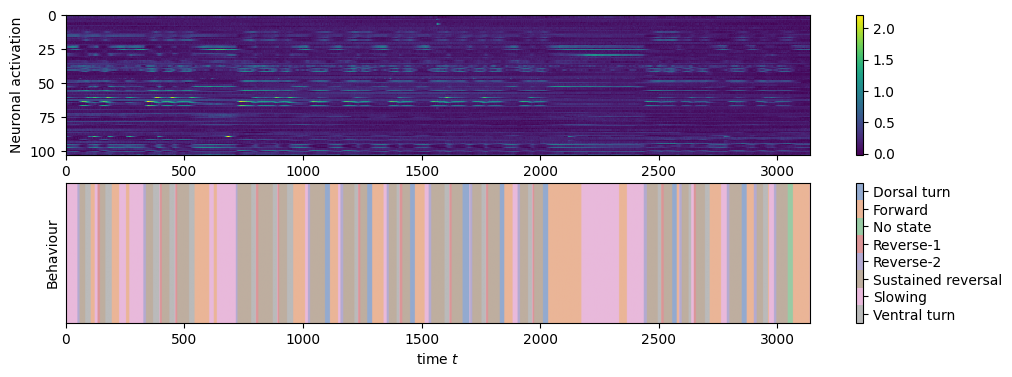

(<Figure size 1200x400 with 4 Axes>,
 array([<Axes: xlabel='time $t$', ylabel='Neuronal activation'>,
        <Axes: xlabel='time $t$', ylabel='Behaviour'>], dtype=object))

In [2]:
worm_num = 0
algorithm = 'BunDLe-Net'
b_neurons = [
    'AVAR',
    'AVAL',
    'SMDVR',
    'SMDVL',
    'SMDDR',
    'SMDDL',
    'RIBR',
    'RIBL'
]
data_path = '../datasets/raw/c_elegans/NoStim_Data.mat'
data = Database(data_path=data_path, dataset_no=worm_num)
data.exclude_neurons(b_neurons)
x = data.neuron_traces.T
b = data.behaviour

plotting_neuronal_behavioural(x, b, b_names=data.behaviour_names)

## Preparing Data for BunDLe-Net  

Ensure that your discrete behavioural labels are consecutive integers from `0` to `n_states -1`. If not, convert them with:

In [3]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
b = label_encoder.fit_transform(b)

The **`prep_data`** function transforms the time-series brain activity (`x`) and behavioral (`b`) data into a format suitable for the **BunDLe-Net** model. The **`win`** parameter specifies the window length, and allows us to perform a time delay embedding:
- **`win=1`**: Embeds a single time step.  
- **`win>1`**: Embeds a window of time-slices.

#### Output Shapes  
- **Neuronal data (`x_`)**: Shaped as **(t - win, 2, win, n)**, where:  
  - `x_[:,0,:,:]` represents $X_t$  
  - `x_[:,1,:,:]` represents $X_{t+1}$
  - the first dim denotes time-steps
  - the last dim denotes feature number (in this case, the neuron number)
- **Behavioral data (`b_`)**: Shaped as **(t - win, ...)** to maintain synchronization with `x_`.  

For this dataset, we do not perform a time delay embedding and thus use `prep_data` with `win=1`:  

In [4]:
print(x.shape, b.shape)
x_, b_ = prep_data(x, b, win=1)
print(x_.shape, b_.shape)

(3137, 103) (3137,)
(3136, 2, 1, 103) (3136,)


## Training BunDLe-Net

Now, train BunDLe-Net on the prepared time-series brain activity and behavioral data.

In [5]:
model = BunDLeNet(latent_dim=3, num_behaviour=len(data.behaviour_names), input_shape=x_.shape)
loss_array, _ = train_model(
    x_,
    b_,
    model,
    b_type='discrete',
    gamma=0.9,
    learning_rate=0.001,
    n_epochs=500
)

Loss [Markov, Behaviour, Total]: [0.0091 0.0084 0.0175]: 100%|█████| 500/500 [00:55<00:00,  8.97it/s]



## Training loss versus epochs

We plot the losses over the epochs in order to check whether the model has converged during training.

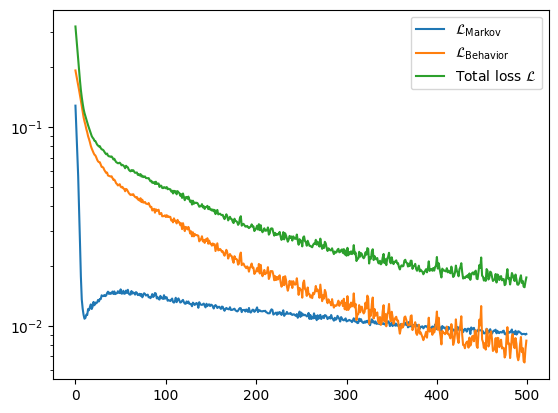

In [6]:
for i, label in enumerate([
    r"$\mathcal{L}_{\mathrm{Markov}}$",
    r"$\mathcal{L}_{\mathrm{Behavior}}$",
    r"Total loss $\mathcal{L}$"
]):
    plt.semilogy(loss_array[:, i], label=label)
plt.legend()
plt.show()

## Projecting into latent space

Once we confirm the model has converged, we project the traces into the learned latent space.

In [7]:
y0_ = project_into_latent_space(x_[:,0], model)

## Visualising embedding
Using the LatentSpaceVisualiser class, we first visualise the embedding as time series to see how the embedding corresponds to behavior.

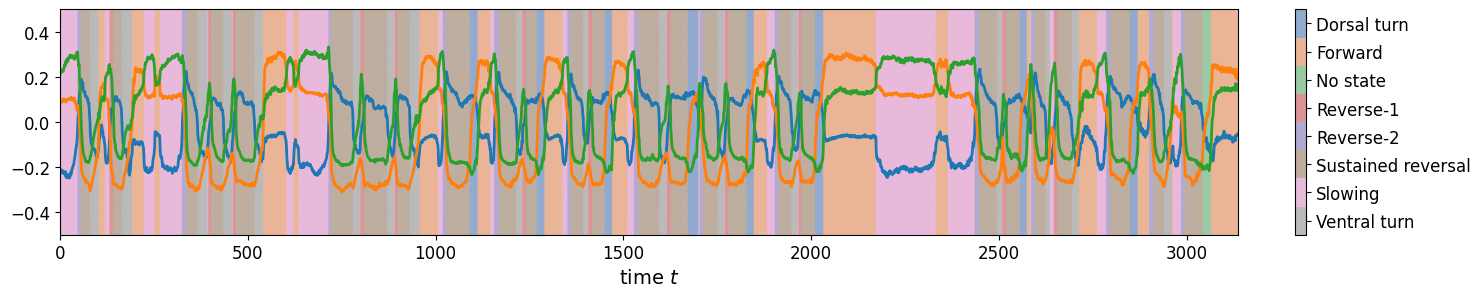

In [8]:
# Plotting latent space dynamics
vis = LatentSpaceVisualiser(y0_, b_, data.behaviour_names)
vis.plot_latent_timeseries(filename = f'../figures/latent_time_series_{algorithm}_worm_{worm_num}.png')

We then use the LatentSpaceVisualiser class to explore the temporal dynamics in phase space (state space). This class allows us to plot arrows between time points at $t$ and $t+1$, helping us identify temporal structures. In the latent space, the branching structure becomes and behavioral motifs become clear.

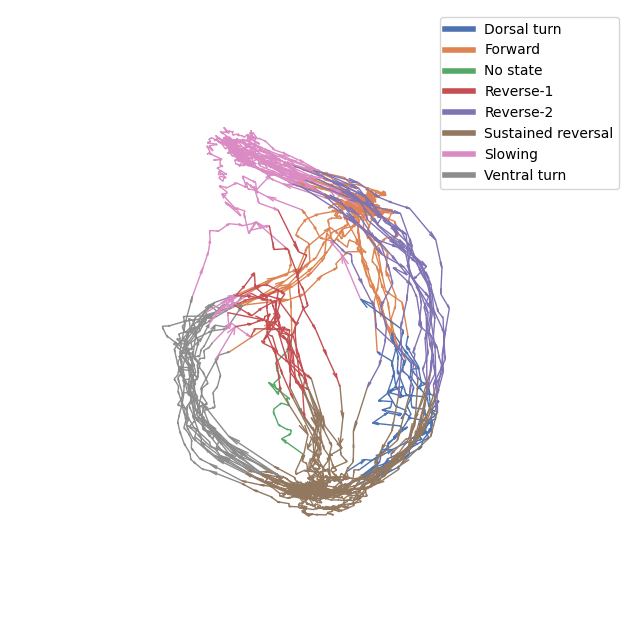

(<Figure size 800x800 with 1 Axes>, <Axes3D: >)

In [9]:
%matplotlib inline
vis.plot_phase_space(filename = f'../figures/phase_space_dynamics_{algorithm}_worm_{worm_num}.png')

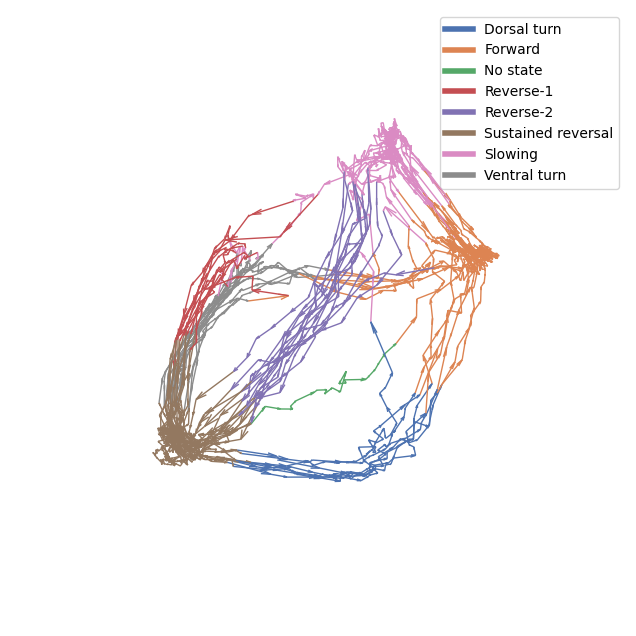

(<Figure size 800x800 with 1 Axes>, <Axes3D: >)

In [10]:
### Run to produce rotating 3-D plot
%matplotlib inline
vis.rotating_plot(filename=f'../figures/rotation_{algorithm}_worm_{worm_num}.gif')

### Recurrence plot analysis of BunDLeNet's embedding

<Figure size 640x480 with 0 Axes>

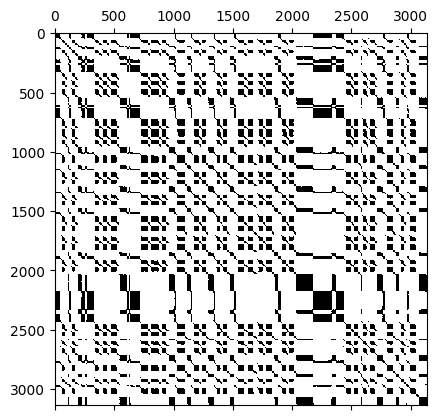

In [11]:
%matplotlib inline
pd_y = np.linalg.norm(y0_[:, np.newaxis] - y0_, axis=-1) < 0.8
plt.figure()
plt.matshow(pd_y, cmap='Greys')
plt.show()